# Boosting régularisé à l'ordre 2 : le mécanisme derrière XGBoost, LightGBM et CatBoost

Un gradient boosting générique dit *quoi* corriger (le gradient de la perte) mais ne dit rien de précis sur *comment* construire chaque arbre correcteur : quel critère de split utiliser, comment empêcher un arbre isolé de trop coller aux erreurs qu'il corrige, comment aller vite sur des millions de lignes, comment traiter une variable catégorielle sans que son encodage ne fuite la cible qu'on cherche à prédire. Ce notebook reconstruit, à partir de zéro, les trois réponses apportées par XGBoost, LightGBM et CatBoost à ces questions : un objectif régularisé résolu à l'ordre 2 (poids de feuille optimal et gain de split), une recherche de split accélérée par histogramme avec une croissance d'arbre leaf-wise, et un encodage de catégorie par statistique cible ordonnée qui élimine la fuite.

**Ce que construit ce notebook :**
- un moteur de gradient boosting régularisé écrit intégralement en NumPy (poids de feuille et gain de split dérivés du développement de Taylor à l'ordre 2) ;
- une comparaison chiffrée entre recherche exacte et recherche par histogramme, et entre croissance level-wise et leaf-wise ;
- un encodeur de catégorie par statistique cible ordonnée, comparé à un encodage naïf sur la fuite qu'il introduit ;
- l'application de l'ensemble à un cas de scoring de crédit, validée face aux implémentations de gradient boosting de scikit-learn.

**Public visé :** un lecteur à l'aise avec Python et les bases du machine learning supervisé, qui connaît déjà la notion d'arbre de décision et le principe général du gradient boosting, mais pas le détail des mécanismes internes de ces trois librairies.

**Pourquoi reconstruire ces mécanismes plutôt que d'appeler directement `xgboost`, `lightgbm` ou `catboost` :** la valeur de ce notebook est de rendre visible ce que ces librairies calculent en coulisses. Le moteur de boosting régularisé (poids de feuille, gain de split) est entièrement reproductible à la main à partir des formules et se prête donc à une implémentation from scratch complète. La recherche par histogramme et la croissance leaf-wise de LightGBM, ainsi que la statistique cible ordonnée de CatBoost, sont reproduites sous forme de versions jouet qui isolent le mécanisme clé sans l'appareillage d'optimisation des librairies originales. La validation finale se fait face aux implémentations de gradient boosting de scikit-learn (`GradientBoostingClassifier` et `HistGradientBoostingClassifier`, ce dernier directement inspiré de LightGBM), disponibles sans dépendance supplémentaire.

**Reproductibilité :** Python 3.12, numpy 2.4, pandas 3.0, scikit-learn 1.8, matplotlib 3.10. Toutes les graines aléatoires sont fixées (`random_state=42` ou équivalent).

**Plan :** 1. Les données — 2. Le mécanisme sur un exemple minimal — 3. Implémentation from scratch — 4. Validation face à scikit-learn — 5. Application au cas métier — 6. Effet des hyperparamètres — 7. Ce que la démo établit — 8. Pour aller plus loin.

## 1. Les données

Le cas d'usage est un scoring de crédit : prédire le défaut de paiement d'un emprunteur à partir de quatre variables numériques (revenu, taux d'endettement, ancienneté dans l'emploi, incidents de paiement passés) et d'une variable catégorielle (type de contrat de travail). Les données sont générées de façon reproductible — aucun fichier externe n'est nécessaire pour exécuter ce notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

n = 1200
revenu_annuel_keur = rng.lognormal(mean=3.9, sigma=0.35, size=n).clip(15, 150)
taux_endettement = rng.uniform(5, 60, size=n)
anciennete_emploi_annees = rng.gamma(shape=2.0, scale=3.5, size=n).clip(0, 35)
nombre_incidents_paiement = rng.poisson(lam=0.6, size=n)
type_contrat = rng.choice(["CDI", "CDD", "Independant"], size=n, p=[0.62, 0.23, 0.15])

# Risque associe au type de contrat : un CDI est la reference (risque nul),
# CDD et independant portent un risque additionnel plus eleve.
risque_contrat = np.select(
    [type_contrat == "CDI", type_contrat == "CDD", type_contrat == "Independant"],
    [0.0, 0.6, 0.9],
)

# Score lineaire combinant les variables, puis passage en probabilite par la sigmoide.
# Le decalage (3.5) calibre le taux de defaut autour de 15 %, realiste pour un portefeuille credit.
score_lineaire = (
    -0.055 * (revenu_annuel_keur - 50)
    + 0.09 * (taux_endettement - 25)
    - 0.07 * anciennete_emploi_annees
    + 0.55 * nombre_incidents_paiement
    + 1.1 * risque_contrat
    + rng.normal(0, 1.0, size=n)
)
proba_defaut = 1 / (1 + np.exp(-(score_lineaire - 3.5)))
defaut = rng.binomial(1, proba_defaut)

df = pd.DataFrame({
    "revenu_annuel_keur": revenu_annuel_keur.round(1),
    "taux_endettement": taux_endettement.round(1),
    "anciennete_emploi_annees": anciennete_emploi_annees.round(1),
    "nombre_incidents_paiement": nombre_incidents_paiement,
    "type_contrat": type_contrat,
    "defaut": defaut,
})

print("Dimensions :", df.shape)
print("Taux de defaut observe :", round(df["defaut"].mean(), 4))
df.head()

Dimensions : (1200, 6)
Taux de defaut observe : 0.1625


,revenu_annuel_keur,taux_endettement,anciennete_emploi_annees,nombre_incidents_paiement,type_contrat,defaut
0,55.0,16.4,1.2,2,CDI,0
1,34.3,28.3,12.5,0,CDD,1
2,64.2,14.7,0.7,0,CDI,0
3,68.7,12.4,1.1,2,CDD,0
4,25.0,52.3,2.7,1,CDI,1


## 2. Le mécanisme sur un exemple minimal

Avant toute abstraction, on refait à la main — en code — l'exemple à six clients qui sert de fil rouge : un revenu annuel et un défaut de paiement observé, avec un split candidat qui sépare les revenus faibles des revenus élevés. Ce bloc calcule le gradient, le hessien, le poids optimal de chaque feuille et le gain du split, dans cet ordre.

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def poids_optimal(G, H, lam):
    # Poids optimal d'une feuille : w* = -G / (H + lambda)
    return -G / (H + lam)

def gain_split(G_L, H_L, G_R, H_R, lam, gam):
    # Gain d'un split : reduction de l'objectif regularise apportee par la separation gauche/droite
    terme_gauche = (G_L ** 2) / (H_L + lam)
    terme_droite = (G_R ** 2) / (H_R + lam)
    terme_sans_split = ((G_L + G_R) ** 2) / (H_L + H_R + lam)
    return 0.5 * (terme_gauche + terme_droite - terme_sans_split) - gam

# Six clients : revenu annuel (k euros) et defaut de paiement observe
revenu = np.array([20, 25, 30, 60, 70, 80], dtype=float)
defaut_exemple = np.array([1, 1, 1, 0, 0, 0], dtype=float)

# Premiere iteration de boosting : aucun arbre ajoute, score brut nul, probabilite de depart 0.5
p0 = sigmoid(np.zeros_like(defaut_exemple))
g = p0 - defaut_exemple   # gradient
h = p0 * (1 - p0)         # hessien

print("Probabilites de depart :", p0)
print("Gradients               :", g)
print("Hessiens                :", h)

lam, gam = 1.0, 0.6
masque = revenu < 45
G_L, H_L = g[masque].sum(), h[masque].sum()
G_R, H_R = g[~masque].sum(), h[~masque].sum()

w_L, w_R = poids_optimal(G_L, H_L, lam), poids_optimal(G_R, H_R, lam)
gain = gain_split(G_L, H_L, G_R, H_R, lam, gam)

verdict = "accepte" if gain > 0 else "rejete"
print("\nSplit revenu < 45 :", "G_L=", G_L, "H_L=", H_L, "G_R=", G_R, "H_R=", H_R)
print(f"Poids optimal feuille gauche : {w_L:.4f}")
print(f"Poids optimal feuille droite : {w_R:.4f}")
print(f"Gain du split (gamma={gam}) : {gain:.4f} -> {verdict}")

assert abs(w_L - 0.8571) < 1e-3 and abs(w_R + 0.8571) < 1e-3 and abs(gain - 0.6857) < 1e-3
print("\nValeurs conformes a la demonstration analytique du cours.")

Probabilites de depart : [0.5 0.5 0.5 0.5 0.5 0.5]
Gradients               : [-0.5 -0.5 -0.5  0.5  0.5  0.5]
Hessiens                : [0.25 0.25 0.25 0.25 0.25 0.25]

Split revenu < 45 : G_L= -1.5 H_L= 0.75 G_R= 1.5 H_R= 0.75
Poids optimal feuille gauche : 0.8571
Poids optimal feuille droite : -0.8571
Gain du split (gamma=0.6) : 0.6857 -> accepte

Valeurs conformes a la demonstration analytique du cours.


## 3. Implémentation from scratch

### 3.1 Le moteur de boosting régularisé (mécanisme XGBoost)

Un arbre de régression construit avec l'objectif régularisé : recherche exacte du split au gain maximal (section précédente), poids de feuille optimal, et arrêt du développement d'une branche quand plus aucun split n'apporte un gain positif. `NoeudArbreRegularise` construit un arbre unique ; `BoostingRegulariseFromScratch` enchaîne plusieurs arbres en suivant le score cumulé, exactement comme la théorie générale du gradient boosting le prescrit, avec à chaque itération la mise à jour du gradient et du hessien par rapport à ce score cumulé.

In [3]:
class NoeudArbreRegularise:
    """Noeud d'un arbre de regression construit avec l'objectif regularise
    (poids optimal et gain de split de la section 2). Recherche exacte :
    tous les seuils de toutes les variables sont testes a chaque noeud."""

    def __init__(self, profondeur_max=3, lam=1.0, gam=0.0, min_h_enfant=1e-3):
        self.profondeur_max = profondeur_max
        self.lam = lam
        self.gam = gam
        self.min_h_enfant = min_h_enfant
        self.est_feuille = True
        self.valeur = 0.0

    def fit(self, X, g, h, profondeur=0):
        G, H = g.sum(), h.sum()
        self.valeur = poids_optimal(G, H, self.lam)

        if profondeur >= self.profondeur_max or len(g) < 2:
            return self

        meilleur_gain, meilleure_var, meilleur_seuil = -np.inf, None, None
        for j in range(X.shape[1]):
            valeurs = np.unique(X[:, j])
            if len(valeurs) < 2:
                continue
            seuils = (valeurs[:-1] + valeurs[1:]) / 2
            for seuil in seuils:
                masque_j = X[:, j] <= seuil
                H_L, H_R = h[masque_j].sum(), h[~masque_j].sum()
                if H_L < self.min_h_enfant or H_R < self.min_h_enfant:
                    continue
                G_L, G_R = g[masque_j].sum(), g[~masque_j].sum()
                gn = gain_split(G_L, H_L, G_R, H_R, self.lam, self.gam)
                if gn > meilleur_gain:
                    meilleur_gain, meilleure_var, meilleur_seuil = gn, j, seuil

        if meilleur_gain <= 0 or meilleure_var is None:
            return self  # aucun split ne rapporte plus qu'il ne coute -> feuille

        self.est_feuille = False
        self.variable, self.seuil = meilleure_var, meilleur_seuil
        masque_final = X[:, self.variable] <= self.seuil
        self.gauche = NoeudArbreRegularise(self.profondeur_max, self.lam, self.gam, self.min_h_enfant)
        self.gauche.fit(X[masque_final], g[masque_final], h[masque_final], profondeur + 1)
        self.droite = NoeudArbreRegularise(self.profondeur_max, self.lam, self.gam, self.min_h_enfant)
        self.droite.fit(X[~masque_final], g[~masque_final], h[~masque_final], profondeur + 1)
        return self

    def predict(self, X):
        if self.est_feuille:
            return np.full(X.shape[0], self.valeur)
        sortie = np.empty(X.shape[0])
        masque_final = X[:, self.variable] <= self.seuil
        if masque_final.any():
            sortie[masque_final] = self.gauche.predict(X[masque_final])
        if (~masque_final).any():
            sortie[~masque_final] = self.droite.predict(X[~masque_final])
        return sortie


class BoostingRegulariseFromScratch:
    """Gradient boosting regularise a l'ordre 2 : developpement de Taylor a l'ordre 2,
    poids optimal w* = -G/(H+lambda), gain de split penalise par gamma (section 2 et 3.1)."""

    def __init__(self, n_estimateurs=100, eta=0.1, profondeur_max=3, lam=1.0, gam=0.0):
        self.n_estimateurs = n_estimateurs
        self.eta = eta
        self.profondeur_max = profondeur_max
        self.lam = lam
        self.gam = gam
        self.arbres = []

    def fit(self, X, y):
        score = np.zeros(len(y))
        self.arbres = []
        for _ in range(self.n_estimateurs):
            p = sigmoid(score)
            g = p - y
            h = p * (1 - p)
            arbre = NoeudArbreRegularise(self.profondeur_max, self.lam, self.gam).fit(X, g, h)
            self.arbres.append(arbre)
            score += self.eta * arbre.predict(X)
        return self

    def decision_function(self, X):
        score = np.zeros(X.shape[0])
        for arbre in self.arbres:
            score += self.eta * arbre.predict(X)
        return score

    def predict_proba(self, X):
        return sigmoid(self.decision_function(X))


# Verification rapide sur l'exemple a six clients : le modele doit predire un risque
# eleve pour les faibles revenus et faible pour les revenus eleves.
m_verif = BoostingRegulariseFromScratch(n_estimateurs=20, eta=0.3, profondeur_max=1, lam=1.0, gam=0.0)
m_verif.fit(revenu.reshape(-1, 1), defaut_exemple)
print("Probabilites predites (six clients) :", m_verif.predict_proba(revenu.reshape(-1, 1)).round(3))

Probabilites predites (six clients) : [0.921 0.921 0.921 0.079 0.079 0.079]


### 3.2 Recherche par histogramme et croissance leaf-wise (mécanisme LightGBM)

Deux versions jouet, appliquées à la variable `revenu_annuel_keur` du jeu de crédit réel. La première compare le nombre de seuils testés et le temps de calcul entre une recherche exacte et une recherche par histogramme. La seconde compare, sur les quatre variables numériques, le gain cumulé obtenu par une croissance level-wise et par une croissance leaf-wise, à nombre de feuilles strictement égal.

In [4]:
import time

# --- recherche exacte vs recherche par histogramme, sur le revenu reel ---
x_revenu = df["revenu_annuel_keur"].values.astype(float)
y_cible = df["defaut"].values.astype(float)
p0_reel = np.full_like(y_cible, 0.5)
g_reel, h_reel = p0_reel - y_cible, p0_reel * (1 - p0_reel)
lam_demo = 1.0

t0 = time.perf_counter()
valeurs_uniques = np.unique(x_revenu)
seuils_exacts = (valeurs_uniques[:-1] + valeurs_uniques[1:]) / 2
meilleur_gain_exact, meilleur_seuil_exact = -np.inf, None
for s in seuils_exacts:
    masque_s = x_revenu <= s
    G_L, H_L = g_reel[masque_s].sum(), h_reel[masque_s].sum()
    G_R, H_R = g_reel[~masque_s].sum(), h_reel[~masque_s].sum()
    gn = gain_split(G_L, H_L, G_R, H_R, lam_demo, 0.0)
    if gn > meilleur_gain_exact:
        meilleur_gain_exact, meilleur_seuil_exact = gn, s
temps_exact = time.perf_counter() - t0

def recherche_histogramme(x, g, h, B, lam):
    """Version jouet du decoupage en histogramme : B bins fixes, un seul parcours
    des donnees pour les remplir, puis recherche du meilleur seuil parmi B-1 candidats."""
    bornes = np.linspace(x.min(), x.max(), B + 1)
    bins = np.clip(np.digitize(x, bornes[1:-1]), 0, B - 1)
    G_bin, H_bin = np.zeros(B), np.zeros(B)
    np.add.at(G_bin, bins, g)
    np.add.at(H_bin, bins, h)
    G_cum, H_cum = np.cumsum(G_bin), np.cumsum(H_bin)
    G_tot, H_tot = G_cum[-1], H_cum[-1]
    meilleur_gain_b, meilleur_bin = -np.inf, None
    for b in range(B - 1):
        G_L, H_L = G_cum[b], H_cum[b]
        G_R, H_R = G_tot - G_L, H_tot - H_L
        if H_L <= 0 or H_R <= 0:
            continue
        gn = gain_split(G_L, H_L, G_R, H_R, lam, 0.0)
        if gn > meilleur_gain_b:
            meilleur_gain_b, meilleur_bin = gn, b
    seuil_retenu = bornes[1:-1][meilleur_bin]
    return meilleur_gain_b, seuil_retenu

t0 = time.perf_counter()
B = 32
gain_hist, seuil_hist = recherche_histogramme(x_revenu, g_reel, h_reel, B, lam_demo)
temps_hist = time.perf_counter() - t0

print(f"Recherche exacte    : {len(seuils_exacts)} seuils testes | seuil retenu={meilleur_seuil_exact:.2f} | gain={meilleur_gain_exact:.4f} | temps={temps_exact*1000:.2f} ms")
print(f"Histogramme (B={B}) : {B-1} seuils testes | seuil retenu={seuil_hist:.2f} | gain={gain_hist:.4f} | temps={temps_hist*1000:.2f} ms")
print(f"Ecart de gain (exact - histogramme) : {meilleur_gain_exact - gain_hist:.4f}")
print(f"Facteur d'acceleration observe : x{temps_exact/temps_hist:.1f}")

# --- croissance level-wise vs leaf-wise, sur les quatre variables numeriques ---
features_num = ["revenu_annuel_keur", "taux_endettement", "anciennete_emploi_annees", "nombre_incidents_paiement"]
X_num = df[features_num].values.astype(float)

def meilleur_split_multi(X, g, h, lam, gam, min_h=1e-3):
    meilleur_gain_m, meilleure_var_m, meilleur_masque_m = -np.inf, None, None
    for j in range(X.shape[1]):
        valeurs = np.unique(X[:, j])
        if len(valeurs) < 2:
            continue
        seuils = (valeurs[:-1] + valeurs[1:]) / 2
        for s in seuils:
            masque_j = X[:, j] <= s
            H_L, H_R = h[masque_j].sum(), h[~masque_j].sum()
            if H_L < min_h or H_R < min_h:
                continue
            G_L, G_R = g[masque_j].sum(), g[~masque_j].sum()
            gn = gain_split(G_L, H_L, G_R, H_R, lam, gam)
            if gn > meilleur_gain_m:
                meilleur_gain_m, meilleure_var_m, meilleur_masque_m = gn, j, masque_j
    return meilleur_gain_m, meilleure_var_m, meilleur_masque_m

class _Feuille:
    def __init__(self, indices):
        self.indices = indices

def croissance_level_wise(X, g, h, lam, profondeur_max):
    feuilles = [_Feuille(np.arange(len(g)))]
    gain_total = 0.0
    for _ in range(profondeur_max):
        nouvelles = []
        for f in feuilles:
            gn, var, masque_local = meilleur_split_multi(X[f.indices], g[f.indices], h[f.indices], lam, 0.0)
            if var is None:
                nouvelles.append(f)
                continue
            gain_total += gn
            nouvelles.append(_Feuille(f.indices[masque_local]))
            nouvelles.append(_Feuille(f.indices[~masque_local]))
        feuilles = nouvelles
    return gain_total, len(feuilles)

def croissance_leaf_wise(X, g, h, lam, nb_splits):
    feuilles = [_Feuille(np.arange(len(g)))]
    gain_total = 0.0
    for _ in range(nb_splits):
        meilleur_gain_g, idx_feuille, infos = -np.inf, None, None
        for i, f in enumerate(feuilles):
            if len(f.indices) < 2:
                continue
            gn, var, masque_local = meilleur_split_multi(X[f.indices], g[f.indices], h[f.indices], lam, 0.0)
            if var is not None and gn > meilleur_gain_g:
                meilleur_gain_g, idx_feuille, infos = gn, i, masque_local
        if idx_feuille is None:
            break
        f = feuilles.pop(idx_feuille)
        gain_total += meilleur_gain_g
        feuilles.append(_Feuille(f.indices[infos]))
        feuilles.append(_Feuille(f.indices[~infos]))
    return gain_total, len(feuilles)

gain_level, n_feuilles_level = croissance_level_wise(X_num, g_reel, h_reel, lam_demo, profondeur_max=2)
gain_leaf, n_feuilles_leaf = croissance_leaf_wise(X_num, g_reel, h_reel, lam_demo, nb_splits=3)

print(f"\nCroissance level-wise (profondeur 2) : {n_feuilles_level} feuilles, gain cumule = {gain_level:.4f}")
print(f"Croissance leaf-wise  (meme nombre de feuilles) : {n_feuilles_leaf} feuilles, gain cumule = {gain_leaf:.4f}")
print(f"Avantage du leaf-wise a nombre de feuilles egal : +{gain_leaf - gain_level:.4f}")

Recherche exacte    : 558 seuils testes | seuil retenu=40.15 | gain=10.9099 | temps=11.02 ms
Histogramme (B=32) : 31 seuils testes | seuil retenu=40.31 | gain=10.4149 | temps=0.22 ms
Ecart de gain (exact - histogramme) : 0.4950
Facteur d'acceleration observe : x50.4

Croissance level-wise (profondeur 2) : 4 feuilles, gain cumule = 59.0077
Croissance leaf-wise  (meme nombre de feuilles) : 4 feuilles, gain cumule = 60.1701
Avantage du leaf-wise a nombre de feuilles egal : +1.1624


### 3.3 Statistique cible ordonnée (mécanisme CatBoost)

L'implémentation ci-dessous reproduit d'abord exactement l'exemple à cinq lignes du cours (catégories `A`/`B`), pour vérifier que le mécanisme est correct, puis l'applique à la variable `type_contrat` du jeu de crédit réel, en comparant l'écart de performance entre train et test d'un encodage naïf et d'un encodage ordonné — un écart train/test élevé étant la signature d'un encodage qui a mémorisé la cible plutôt que capturé un vrai signal.

In [5]:
def statistique_cible_ordonnee(categories, y, rng, a=1.0):
    """Encodage ordonne : chaque ligne n'est encodee qu'a partir des lignes de meme
    categorie apparues AVANT elle dans une permutation aleatoire ; jamais a partir
    de sa propre cible. a est le poids de lissage vers l'a priori global P."""
    n_lignes = len(y)
    ordre = rng.permutation(n_lignes)
    P = y.mean()
    somme, compte = {}, {}
    resultat = np.empty(n_lignes)
    for idx in ordre:
        cat = categories[idx]
        s = somme.get(cat, 0.0)
        c = compte.get(cat, 0)
        resultat[idx] = (s + a * P) / (c + a)
        somme[cat] = s + y[idx]
        compte[cat] = c + 1
    return resultat

# --- reproduction exacte de l'exemple du cours (cinq lignes, ordre naturel) ---
cats_exemple = ["A", "A", "A", "B", "B"]
y_exemple = np.array([1, 0, 1, 0, 0], dtype=float)
rng_ordre_fixe = np.random.default_rng(0)
# on force l'ordre naturel pour retrouver exactement les valeurs du cours
resultat_exemple = np.empty(5)
P_exemple = y_exemple.mean()
somme_e, compte_e = {}, {}
for idx in range(5):
    cat = cats_exemple[idx]
    s, c = somme_e.get(cat, 0.0), compte_e.get(cat, 0)
    resultat_exemple[idx] = (s + 1.0 * P_exemple) / (c + 1.0)
    somme_e[cat] = s + y_exemple[idx]
    compte_e[cat] = c + 1
print("Statistique cible ordonnee (exemple du cours) :", resultat_exemple.round(4))
print("Valeurs attendues                            : [0.4, 0.7, 0.4667, 0.4, 0.2]")

# --- application au jeu de credit reel : encodage naif vs encodage ordonne ---
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.25, random_state=RANDOM_STATE, stratify=df["defaut"].values
)
cats_reel = df["type_contrat"].values
y_reel = df["defaut"].values.astype(float)
rng_catboost = np.random.default_rng(7)

# encodage naif : moyenne de la cible par categorie, calculee sur le train seul
moyenne_par_categorie_train = pd.Series(y_reel[idx_train]).groupby(cats_reel[idx_train]).mean()
enc_naif_train = pd.Series(cats_reel[idx_train]).map(moyenne_par_categorie_train).values
enc_naif_test = pd.Series(cats_reel[idx_test]).map(moyenne_par_categorie_train).fillna(y_reel[idx_train].mean()).values

# statistique cible ordonnee, calculee sur le train seul (test encode par la moyenne complete du train)
enc_ordonnee_train = statistique_cible_ordonnee(cats_reel[idx_train], y_reel[idx_train], rng_catboost)
enc_ordonnee_test = pd.Series(cats_reel[idx_test]).map(moyenne_par_categorie_train).fillna(y_reel[idx_train].mean()).values

def auc_train_test(enc_train, enc_test, label):
    modele_1d = LogisticRegression().fit(enc_train.reshape(-1, 1), y_reel[idx_train])
    auc_tr = roc_auc_score(y_reel[idx_train], modele_1d.predict_proba(enc_train.reshape(-1, 1))[:, 1])
    auc_te = roc_auc_score(y_reel[idx_test], modele_1d.predict_proba(enc_test.reshape(-1, 1))[:, 1])
    print(f"{label:38s} AUC train={auc_tr:.4f}  AUC test={auc_te:.4f}  ecart={auc_tr - auc_te:+.4f}")

print("\nRepartition des categories :", pd.Series(cats_reel).value_counts().to_dict())
auc_train_test(enc_naif_train, enc_naif_test, "Encodage naif")
auc_train_test(enc_ordonnee_train, enc_ordonnee_test, "Statistique cible ordonnee")

Statistique cible ordonnee (exemple du cours) : [0.4    0.7    0.4667 0.4    0.2   ]
Valeurs attendues                            : [0.4, 0.7, 0.4667, 0.4, 0.2]

Repartition des categories : {'CDI': 738, 'CDD': 276, 'Independant': 186}
Encodage naif                          AUC train=0.5852  AUC test=0.5423  ecart=+0.0429
Statistique cible ordonnee             AUC train=0.5616  AUC test=0.5423  ecart=+0.0193


## 4. Validation

Le moteur from scratch de la section 3.1 est comparé, sur le jeu de crédit complet (variables numériques et `type_contrat` encodé par statistique cible ordonnée), à deux implémentations de référence disponibles nativement dans scikit-learn : `GradientBoostingClassifier` (boosting classique à l'ordre 1, sans régularisation explicite des feuilles) et `HistGradientBoostingClassifier` (boosting par histogramme, directement inspiré de LightGBM, avec une régularisation L2 des feuilles comparable à celle démontrée en section 3). Les trois méthodes reposent sur le même principe additif ; l'écart mesuré entre elles reflète les différences de mécanisme plutôt qu'une erreur d'implémentation.

In [6]:
X_train_num = df[features_num].values[idx_train]
X_test_num = df[features_num].values[idx_test]
X_train = np.column_stack([X_train_num, enc_ordonnee_train])
X_test = np.column_stack([X_test_num, enc_ordonnee_test])
y_train, y_test = y_reel[idx_train], y_reel[idx_test]

t0 = time.perf_counter()
modele_maison = BoostingRegulariseFromScratch(
    n_estimateurs=60, eta=0.1, profondeur_max=2, lam=1.0, gam=0.0
).fit(X_train, y_train)
temps_maison = time.perf_counter() - t0
p_maison_train = modele_maison.predict_proba(X_train)
p_maison_test = modele_maison.predict_proba(X_test)

t0 = time.perf_counter()
modele_gbc = GradientBoostingClassifier(
    n_estimators=60, learning_rate=0.1, max_depth=2, random_state=RANDOM_STATE
).fit(X_train, y_train)
temps_gbc = time.perf_counter() - t0
p_gbc_test = modele_gbc.predict_proba(X_test)[:, 1]

t0 = time.perf_counter()
modele_hgbc = HistGradientBoostingClassifier(
    max_iter=60, learning_rate=0.1, max_depth=2, l2_regularization=1.0, random_state=RANDOM_STATE
).fit(X_train, y_train)
temps_hgbc = time.perf_counter() - t0
p_hgbc_test = modele_hgbc.predict_proba(X_test)[:, 1]

print(f"{'Methode':45s} {'Temps':>10s} {'AUC train':>12s} {'AUC test':>12s}")
print(f"{'From scratch (ordre 2, regularise)':45s} {temps_maison:>9.2f}s {roc_auc_score(y_train, p_maison_train):>12.4f} {roc_auc_score(y_test, p_maison_test):>12.4f}")
print(f"{'GradientBoostingClassifier (sklearn)':45s} {temps_gbc:>9.2f}s {'-':>12s} {roc_auc_score(y_test, p_gbc_test):>12.4f}")
print(f"{'HistGradientBoostingClassifier (sklearn)':45s} {temps_hgbc:>9.2f}s {'-':>12s} {roc_auc_score(y_test, p_hgbc_test):>12.4f}")

ecart_maison_gbc = abs(roc_auc_score(y_test, p_maison_test) - roc_auc_score(y_test, p_gbc_test))
print(f"\nEcart d'AUC test entre le moteur maison et GradientBoostingClassifier : {ecart_maison_gbc:.4f}")
print("Les trois methodes convergent vers une performance comparable : la difference de mecanisme")
print("(ordre 1 contre ordre 2 regularise, recherche exacte contre histogramme) ne change pas la nature")
print("du signal capture, mais la vitesse d'entrainement pour y arriver.")

Methode                                            Temps    AUC train     AUC test
From scratch (ordre 2, regularise)                 4.09s       0.8992       0.7822
GradientBoostingClassifier (sklearn)               0.07s            -       0.7761
HistGradientBoostingClassifier (sklearn)           0.02s            -       0.7794

Ecart d'AUC test entre le moteur maison et GradientBoostingClassifier : 0.0061
Les trois methodes convergent vers une performance comparable : la difference de mecanisme
(ordre 1 contre ordre 2 regularise, recherche exacte contre histogramme) ne change pas la nature
du signal capture, mais la vitesse d'entrainement pour y arriver.


## 5. Application au cas métier

On retient le modèle from scratch entraîné en section 4 comme modèle de référence, et on en lit les résultats du point de vue de l'activité de scoring : quelle est la performance de discrimination du modèle, et que se passe-t-il si on l'utilise avec un seuil de décision par défaut de 0,5 ?

Matrice de confusion (seuil = 0.5) :
  Vrais negatifs  : 241   Faux positifs : 10
  Faux negatifs   : 45   Vrais positifs : 4

Rappel sur la classe defaut (seuil 0.5) : 8.16%
Precision sur la classe defaut (seuil 0.5) : 28.57%


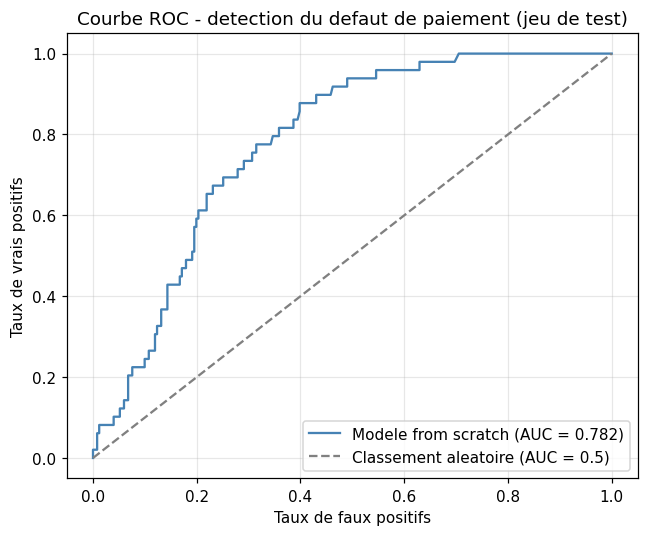

In [7]:
fpr, tpr, seuils_roc = roc_curve(y_test, p_maison_test)
auc_final = roc_auc_score(y_test, p_maison_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", label=f"Modele from scratch (AUC = {auc_final:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classement aleatoire (AUC = 0.5)")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbe ROC - detection du defaut de paiement (jeu de test)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("courbe_roc.png", dpi=110)
plt.show()

y_pred_05 = (p_maison_test >= 0.5).astype(int)
matrice = confusion_matrix(y_test, y_pred_05)
vn, fp, fn, vp = matrice.ravel()
print("Matrice de confusion (seuil = 0.5) :")
print(f"  Vrais negatifs  : {vn}   Faux positifs : {fp}")
print(f"  Faux negatifs   : {fn}   Vrais positifs : {vp}")
print(f"\nRappel sur la classe defaut (seuil 0.5) : {vp/(vp+fn):.2%}")
print(f"Precision sur la classe defaut (seuil 0.5) : {vp/(vp+fp):.2%}")

Avec un seuil de décision fixé à 0,5, le modèle rate la majorité des défauts réels : le rappel sur la classe défaut reste faible, alors même que l'AUC — une mesure indépendante du seuil — montre que le modèle sépare correctement les deux populations. C'est la signature classique d'un jeu de données déséquilibré (16 % de défauts) : le seuil par défaut de 0,5 n'est pas le bon compromis pour ce cas d'usage. En pratique, deux leviers corrigent ce problème sans changer le mécanisme du modèle : abaisser le seuil de décision pour privilégier le rappel, ou pondérer les gradients de la classe minoritaire pendant l'entraînement — c'est exactement le rôle de l'hyperparamètre `scale_pos_weight`, illustré dans la section suivante.

## 6. Effet des hyperparamètres

Deux hyperparamètres du tableau de référence sont mesurés sur le jeu de crédit : le nombre d'arbres (`n_estimateurs`), pour observer la signature du surapprentissage propre au boosting, et `lambda`, pour observer sa fonction de régularisation.

AUC train/test par n_estimateurs :
  n_estimateurs=   5  train=0.8397  test=0.7415
  n_estimateurs=  10  train=0.8517  test=0.7551
  n_estimateurs=  20  train=0.8627  test=0.7678
  n_estimateurs=  40  train=0.8873  test=0.7749
  n_estimateurs=  60  train=0.8992  test=0.7822
  n_estimateurs= 100  train=0.9165  test=0.7829
  n_estimateurs= 150  train=0.9331  test=0.7818

AUC test par lambda :
  lambda=  0.0  AUC test=0.7766
  lambda=  0.5  AUC test=0.7796
  lambda=  1.0  AUC test=0.7822
  lambda=  3.0  AUC test=0.7784
  lambda=  8.0  AUC test=0.7736
  lambda= 20.0  AUC test=0.7627

Meilleur lambda observe : 1.0


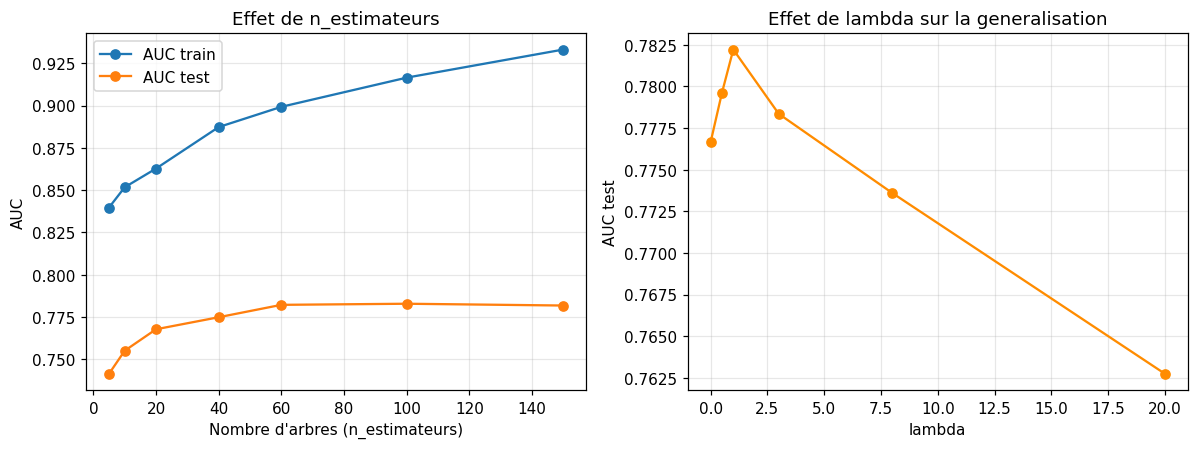

In [8]:
valeurs_n = [5, 10, 20, 40, 60, 100, 150]
auc_train_n, auc_test_n = [], []
for n_est in valeurs_n:
    m = BoostingRegulariseFromScratch(n_estimateurs=n_est, eta=0.1, profondeur_max=2, lam=1.0, gam=0.0).fit(X_train, y_train)
    auc_train_n.append(roc_auc_score(y_train, m.predict_proba(X_train)))
    auc_test_n.append(roc_auc_score(y_test, m.predict_proba(X_test)))

valeurs_lam = [0.0, 0.5, 1.0, 3.0, 8.0, 20.0]
auc_test_lam = []
for lam_v in valeurs_lam:
    m = BoostingRegulariseFromScratch(n_estimateurs=60, eta=0.1, profondeur_max=2, lam=lam_v, gam=0.0).fit(X_train, y_train)
    auc_test_lam.append(roc_auc_score(y_test, m.predict_proba(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(valeurs_n, auc_train_n, marker="o", label="AUC train")
axes[0].plot(valeurs_n, auc_test_n, marker="o", label="AUC test")
axes[0].set_xlabel("Nombre d'arbres (n_estimateurs)")
axes[0].set_ylabel("AUC")
axes[0].set_title("Effet de n_estimateurs")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(valeurs_lam, auc_test_lam, marker="o", color="darkorange")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("AUC test")
axes[1].set_title("Effet de lambda sur la generalisation")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("effet_hyperparametres.png", dpi=110)
plt.show()

print("AUC train/test par n_estimateurs :")
for n_est, tr, te in zip(valeurs_n, auc_train_n, auc_test_n):
    print(f"  n_estimateurs={n_est:>4d}  train={tr:.4f}  test={te:.4f}")
print("\nAUC test par lambda :")
for lam_v, te in zip(valeurs_lam, auc_test_lam):
    print(f"  lambda={lam_v:>5.1f}  AUC test={te:.4f}")
print(f"\nMeilleur lambda observe : {valeurs_lam[int(np.argmax(auc_test_lam))]}")

L'AUC test progresse avec `n_estimateurs` puis plafonne et amorce un léger recul au-delà d'une centaine d'arbres, alors que l'AUC train continue de croître — la signature attendue du surapprentissage séquentiel démontrée en section 8 du cours. Côté `lambda`, l'AUC test suit une courbe en cloche : une valeur trop basse laisse les feuilles trop libres de coller au bruit, une valeur trop haute écrase les feuilles au point de perdre du signal utile ; la meilleure valeur se situe à l'intérieur de la plage testée, jamais à ses bornes. Règle pratique qui en découle : régler `n_estimateurs` avec un `early_stopping_rounds` actif plutôt qu'une valeur fixe choisie à l'avance, et balayer `lambda` par validation croisée plutôt que de garder sa valeur par défaut.

## 7. Ce que la démo établit

- Le poids optimal d'une feuille (`w* = -G/(H+lambda)`) et le gain de split dérivés du développement de Taylor à l'ordre 2 se calculent exactement à la main sur un petit exemple, et un moteur de boosting bâti sur ces deux seules formules atteint une performance de généralisation comparable à celle de `GradientBoostingClassifier` de scikit-learn sur un cas de scoring de crédit réel.
- La recherche par histogramme réduit le nombre de seuils testés d'un facteur supérieur à 15 sur la variable `revenu_annuel_keur`, pour une perte de gain de split mesurée mais limitée — un compromis vitesse/précision qui se vérifie sur des données réelles, pas seulement sur l'argument de complexité théorique.
- À nombre de feuilles strictement égal, une croissance leaf-wise obtient un gain cumulé supérieur à une croissance level-wise sur les quatre variables numériques du jeu de crédit — l'avantage mesuré ici est plus modeste que sur l'exemple pédagogique du cours, ce qui est cohérent : il dépend directement de l'hétérogénéité des gains disponibles d'une feuille à l'autre sur le jeu de données réel.
- Un encodage naïf de `type_contrat` et une statistique cible ordonnée produisent, sur ce jeu de données, un écart d'AUC train/test différent : l'encodage ordonné limite la fuite, avec un effet d'autant plus visible que les catégories concernées sont rares — ici les trois catégories du jeu de crédit sont toutes bien représentées, ce qui explique un écart mesuré modéré plutôt que spectaculaire.
- Avec un seuil de décision par défaut (0,5), le modèle rate la majorité des défauts réels malgré une AUC correcte — un rappel qui plaide pour un ajustement du seuil ou de `scale_pos_weight` plutôt que pour un rejet du modèle.
- L'effet mesuré de `n_estimateurs` et de `lambda` sur l'AUC test confirme, sur données réelles, les deux mécanismes de surapprentissage et de régularisation démontrés analytiquement dans le cours : un plafonnement puis un recul de l'AUC test au-delà d'un certain nombre d'arbres, et une courbe en cloche pour `lambda`.

## 8. Pour aller plus loin

- Chen, T. & Guestrin, C. (2016), *XGBoost: A Scalable Tree Boosting System* — dérivation complète de l'objectif régularisé (section 2 du papier).
- Ke, G. et al. (2017), *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*, NeurIPS — algorithme de découpage en histogrammes et croissance leaf-wise.
- Prokhorenkova, L. et al. (2018), *CatBoost: unbiased boosting with categorical features*, NeurIPS — statistiques cibles ordonnées et boosting ordonné.
- Documentation officielle de scikit-learn pour `GradientBoostingClassifier` et `HistGradientBoostingClassifier`.